# Non-Chaotic Multidimensional Flows

We consider the van der Pol oscillator, $$\begin{align}\frac{dx}{dt} &= y\\ \frac{dy}{dt} &= b(1-x^2)y - x.\end{align}$$

In [10]:
import numpy as np
import matplotlib.pyplot as plt

### Nonlinear ODE solutions using Runge-Kutta integration

In [26]:
# runge-kutta fourth-order integrator
def rk4(f, t0, tf, x0, dt, substeps=4, f_args=()):
    t = np.arange(t0, tf + dt, dt)
    x = np.empty((t.size, len(x0)), dtype=float)
    x[0] = np.array(x0, dtype=float)
    h = dt / substeps

    # integrate
    for n in range(t.size - 1):
        tn = t[n]
        xn = x[n].copy()
        # internal substeps for stability/accuracy
        for _ in range(substeps):
            k1 = f(tn, xn, *f_args)
            k2 = f(tn + 0.5 * h, xn + 0.5 * h * k1, *f_args)
            k3 = f(tn + 0.5 * h, xn + 0.5 * h * k2, *f_args)
            k4 = f(tn + h, xn + h * k3, *f_args)
            xn = xn + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
            tn = tn + h
        x[n + 1] = xn

    return t, x

### Investigating solution when $b = 0$

We get a circular limit cycle, shown below.

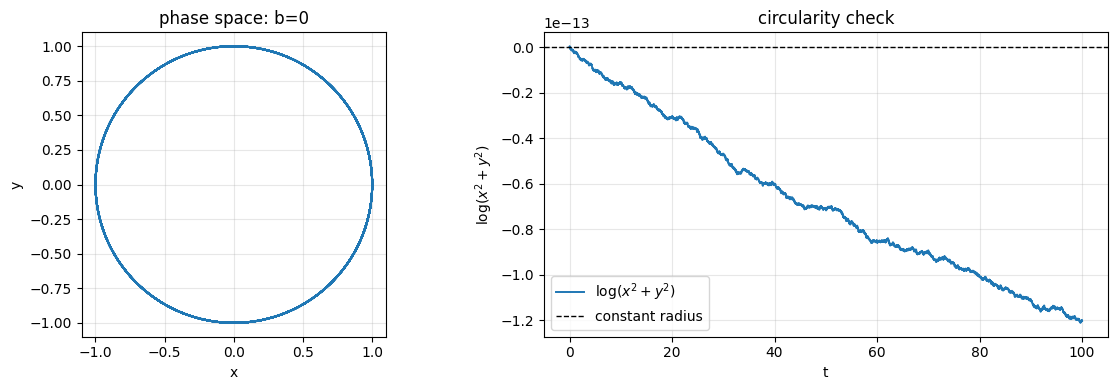

min(r^2), max(r^2): 0.9999999999998789 1.0000000000000004
expected log(r^2): 0.0
max |log(r^2)-expected|: 1.2112533198661192e-13


In [27]:
# parameters
b = 0.0
t0, tf = 0.0, 100.0
dt = 0.01
x0 = np.array([1.0, 0.0])  # x(0)=1, y(0)=0

# van der pol oscillator eqns
def van_der_pol(t, x):
    dx_dt = x[1]
    dy_dt = b * (1.0 - x[0]**2) * x[1] - x[0]
    return np.array([dx_dt, dy_dt], dtype=float)

# integrate
t, x = rk4(van_der_pol, t0, tf, x0, dt)
x_t = x[:, 0]
y_t = x[:, 1]

# circularity check: r^2 = x^2 + y^2 should be constant for b=0
r2 = x_t**2 + y_t**2
log_r2 = np.log(r2)
log_r2_expected = np.log(x0[0]**2 + x0[1]**2)

# side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# phase-space trajectory
ax[0].plot(x_t, y_t, lw=1.4)
ax[0].set_title('phase space: b=0')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].set_aspect('equal', adjustable='box')
ax[0].grid(alpha=0.3)

# log(r^2) over time
ax[1].plot(t, log_r2, lw=1.4, label=r'$\log(x^2+y^2)$')
ax[1].axhline(log_r2_expected, color='k', ls='--', lw=1.0, label='constant radius')
ax[1].set_title(r'circularity check')
ax[1].set_xlabel('t')
ax[1].set_ylabel(r'$\log(x^2+y^2)$')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# quick numeric check: proves that r^2 is nearly 1 throughout
print('min(r^2), max(r^2):', r2.min(), r2.max())
print('expected log(r^2):', log_r2_expected)
print('max |log(r^2)-expected|:', np.max(np.abs(log_r2 - log_r2_expected)))

### Investigating solution when $b = 1$

We converge to limit cycle, shown below.

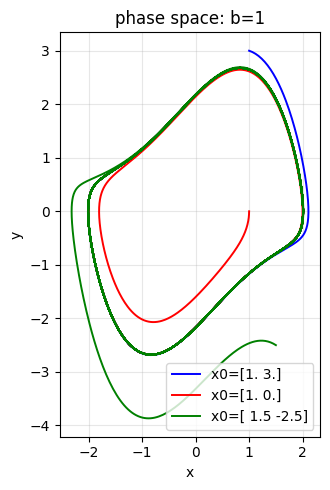

In [21]:
b = 1.0
x0s = [np.array([1.0, 3.0]), np.array([1.0, 0.0]), np.array([1.5, -2.5])]
colors = ['blue', 'red', 'green']

plt.figure(figsize=(5, 5))
for x0, color in zip(x0s, colors):
    t, x = rk4(van_der_pol, t0, tf, x0, dt)
    x_t = x[:, 0]
    y_t = x[:, 1]
    plt.plot(x_t, y_t, lw=1.4, color=color, label=f'x0={x0}')

plt.title('phase space: b=1')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.tight_layout()
plt.show()

### Investigating solutions over a range of $b$

We can see higher distortion and expansion from circular, to elliptical, and finally more pinched and stretched elliptical limit cycles as $b$ increases, starting from 0.

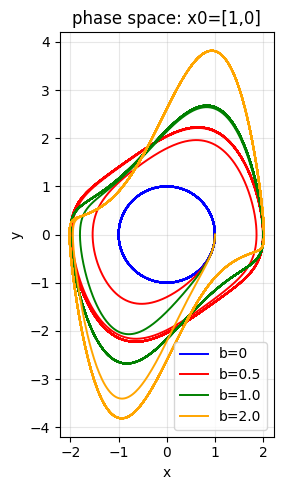

In [24]:
x0 = np.array([1.0, 0.0])
bs = [0, 0.5, 1.0, 2.0]
colors = ['blue', 'red', 'green', 'orange']

plt.figure(figsize=(5, 5))
for b, color in zip(bs, colors):
    t, x = rk4(van_der_pol, t0, tf, x0, dt)
    x_t = x[:, 0]
    y_t = x[:, 1]
    plt.plot(x_t, y_t, lw=1.4, color=color, label=f'b={b}')
    
plt.title('phase space: x0=[1,0]')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.tight_layout()
plt.show()

On the other hand, if $b$ decreases starting from 0, we get a point attractor.

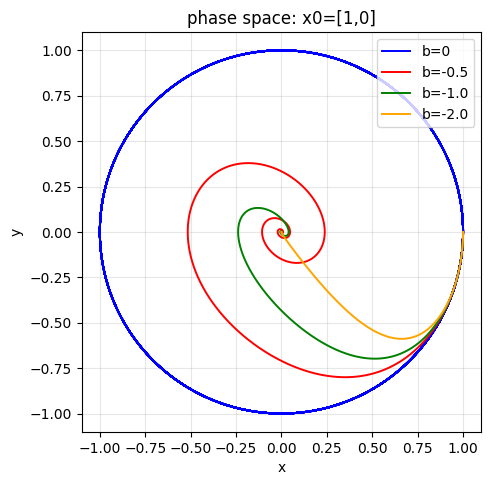

In [25]:
x0 = np.array([1.0, 0.0])
bs = [0, -0.5, -1.0, -2.0]
colors = ['blue', 'red', 'green', 'orange']

plt.figure(figsize=(5, 5))
for b, color in zip(bs, colors):
    t, x = rk4(van_der_pol, t0, tf, x0, dt)
    x_t = x[:, 0]
    y_t = x[:, 1]
    plt.plot(x_t, y_t, lw=1.4, color=color, label=f'b={b}')
    
plt.title('phase space: x0=[1,0]')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.tight_layout()
plt.show()

### Periodically driven van der Pol oscillator

We now consider the oscillator with an external, periodic drive  $$\begin{align*}\frac{dx}{dt} &= y\tag{3}\\ \frac{dy}{dt} &= b(1-x^2)y - x + A\sin(\Omega t).\tag{4}\end{align*}$$

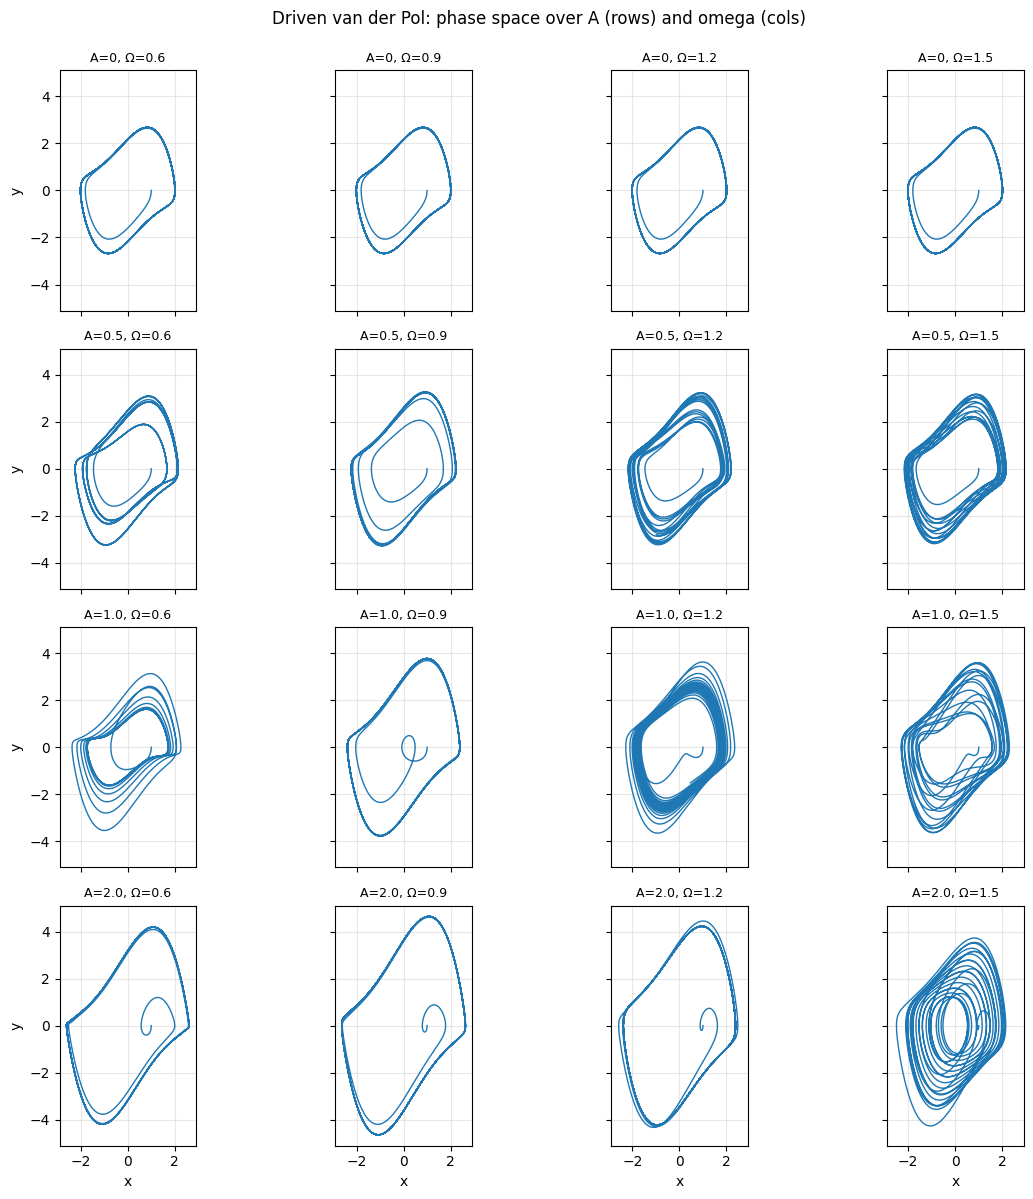

In [29]:
b = 1
As = [0, 0.5, 1.0, 2.0]
omegas = [0.6, 0.9, 1.2, 1.5]
x0 = np.array([1.0, 0.0])  # x(0)=1, y(0)=0

# van der pol driven oscillator
def driven_van_der_pol(t, x, A, omega):
    dx_dt = x[1]
    dy_dt = b * (1.0 - x[0]**2) * x[1] - x[0] + A*np.sin(omega*t)
    return np.array([dx_dt, dy_dt], dtype=float)

fig, ax = plt.subplots(4, 4, figsize=(12, 12), sharex=True, sharey=True)

for i, A in enumerate(As):
    for j, omega in enumerate(omegas):
        # integrate
        t, x = rk4(driven_van_der_pol, t0, tf, x0, dt, f_args=(A, omega))
        x_t = x[:, 0]
        y_t = x[:, 1]

        ax[i, j].plot(x_t, y_t, lw=1.0)
        ax[i, j].set_title(f"A={A}, Ω={omega}", fontsize=9)
        ax[i, j].grid(alpha=0.3)
        if i == 3:
            ax[i, j].set_xlabel("x")
        if j == 0:
            ax[i, j].set_ylabel("y")

for i in range(4):
    for j in range(4):
        ax[i, j].set_aspect("equal", adjustable="box")
fig.suptitle("Driven van der Pol: phase space over A (rows) and omega (cols)", y=0.995)
plt.tight_layout()
plt.show()

From above, it is evident that when $\Omega$ is close to the van der Pol oscillator's natural frequency (~$0.94$ Hz; for $b=1$), then no matter the drive magnitude, the solution locks to the limit cycle, albeit with the adjusted size. In other cases, it locks if the frequency is close enough or if the magnitude of drive is strong enough. If both drive magnitude and frequency deviation are large, then it exhibits quasiperiodic, or even drifting, behavior.